In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("creditcard.csv")

## Dataset Overview

This dataset contains credit card transaction records, including anonymized features, transaction amount, transaction time, and transaction class.

### Business Objective

The objective is to identify fraudulent transactions using machine learning techniques.

### Why It Matters

Fraud detection systems help:

- Prevent financial losses
- Protect customers
- Improve transaction security
- Enhance trust in digital payment systems

In [3]:
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
data.shape

(284807, 31)

### Observation

- The dataset contains numerical features.
- The target variable indicates whether a transaction is fraudulent.
- Fraudulent transactions are significantly fewer than normal transactions.

### Insight

Understanding the data structure helps identify preprocessing and imbalance handling requirements.

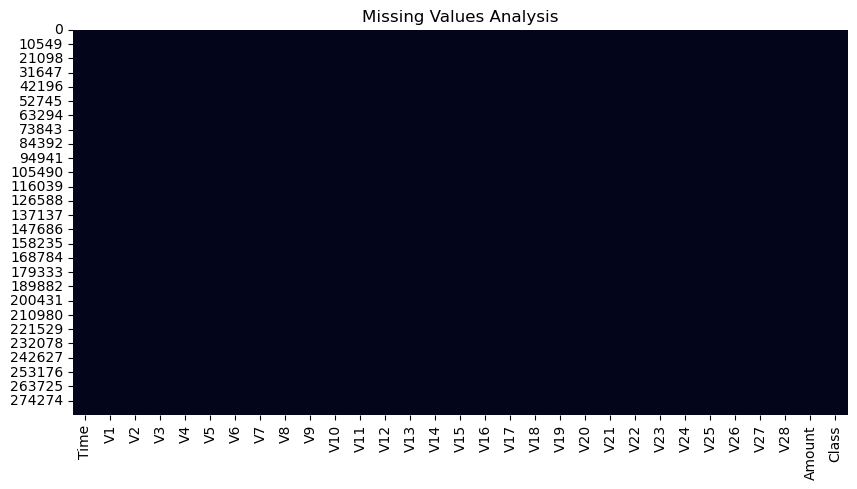

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Analysis")
plt.show()

### Observation

The heatmap shows the presence or absence of missing values.

### Insight

Missing values can negatively impact fraud detection accuracy.

### Business Impact

Accurate transaction data is essential for reliable fraud monitoring.

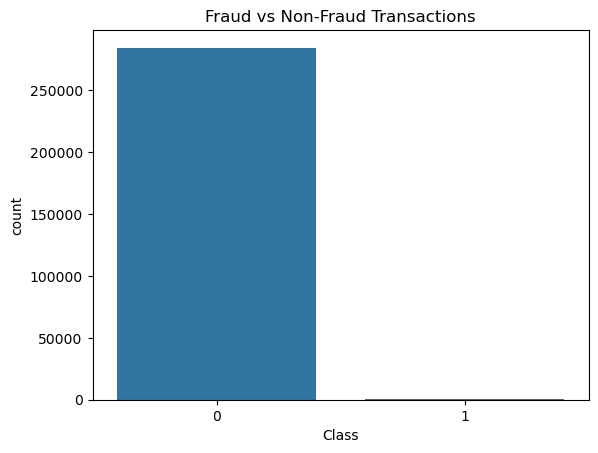

In [11]:
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

### Observation

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of total transactions.

### Insight

Class imbalance can bias machine learning models toward predicting normal transactions.

### Business Impact

Special techniques such as oversampling or class weighting may be required to improve fraud detection.

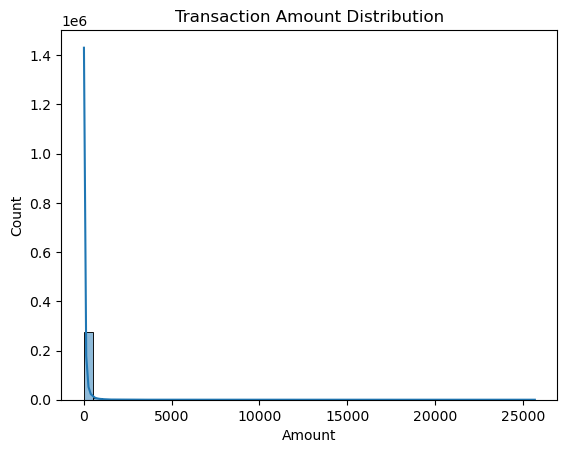

In [12]:
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

### Observation

Most transactions involve relatively small amounts, while a few transactions represent very high values.

### Insight

Transaction amount may contribute to identifying unusual spending patterns.

### Business Impact

Large transactions often require additional fraud screening.

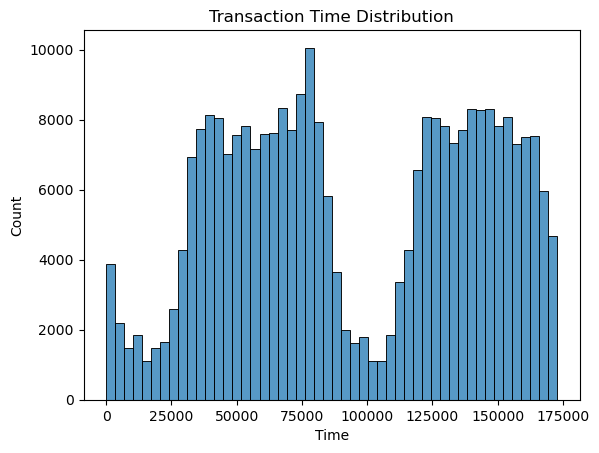

In [13]:
sns.histplot(data['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

### Observation

Transactions occur throughout different time periods.

### Insight

Fraudulent activities may cluster around specific times.

### Business Impact

Time-based monitoring can improve fraud prevention strategies.

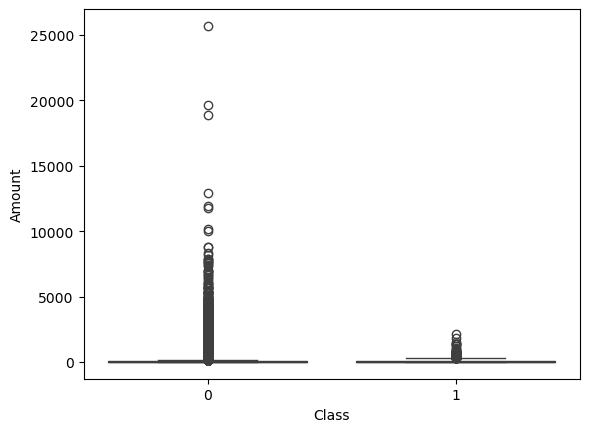

In [14]:
sns.boxplot(x='Class', y='Amount', data=data)
plt.show()

### Observation

Fraudulent transactions often exhibit different amount patterns compared to legitimate transactions.

### Insight

Transaction value can provide useful signals for fraud detection.

### Business Impact

Identifying abnormal transaction amounts can help prevent financial losses.

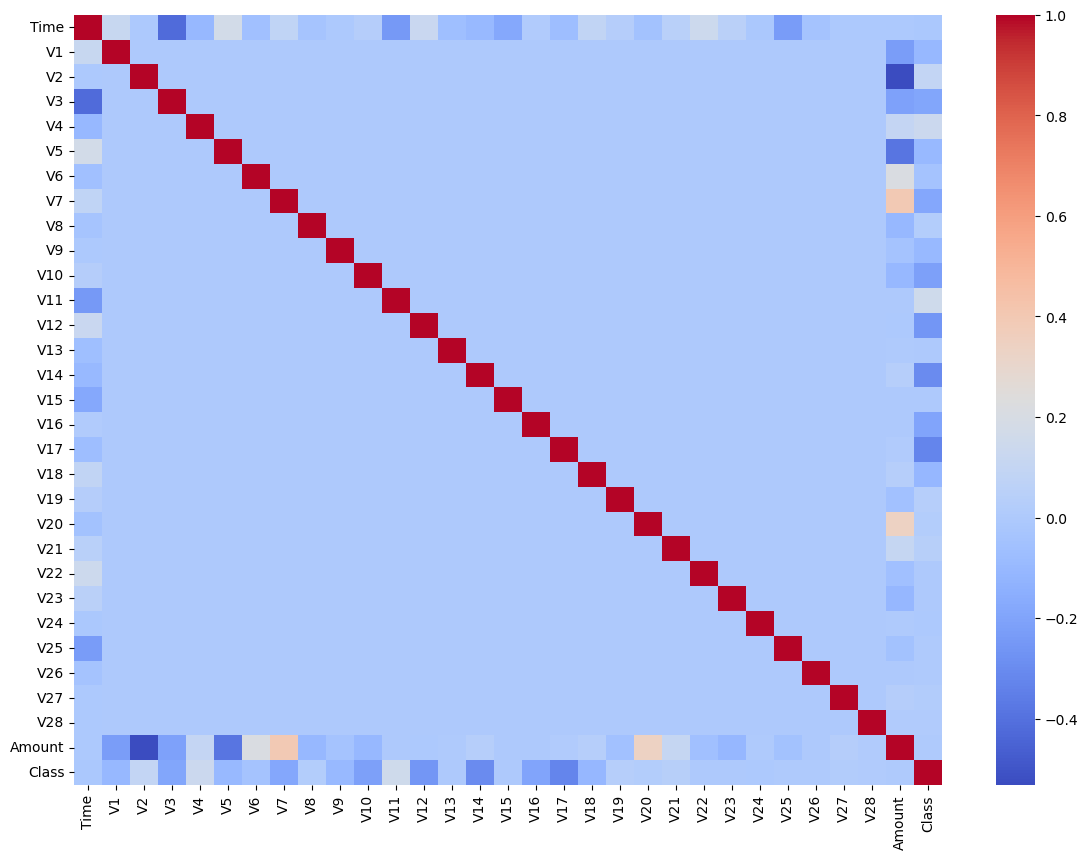

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

### Observation

The heatmap reveals relationships among transaction features.

### Key Findings

- Certain variables show stronger associations with fraudulent behavior.
- Most anonymized features remain independent.

### Insight

Feature relationships help identify variables that contribute most to fraud prediction.

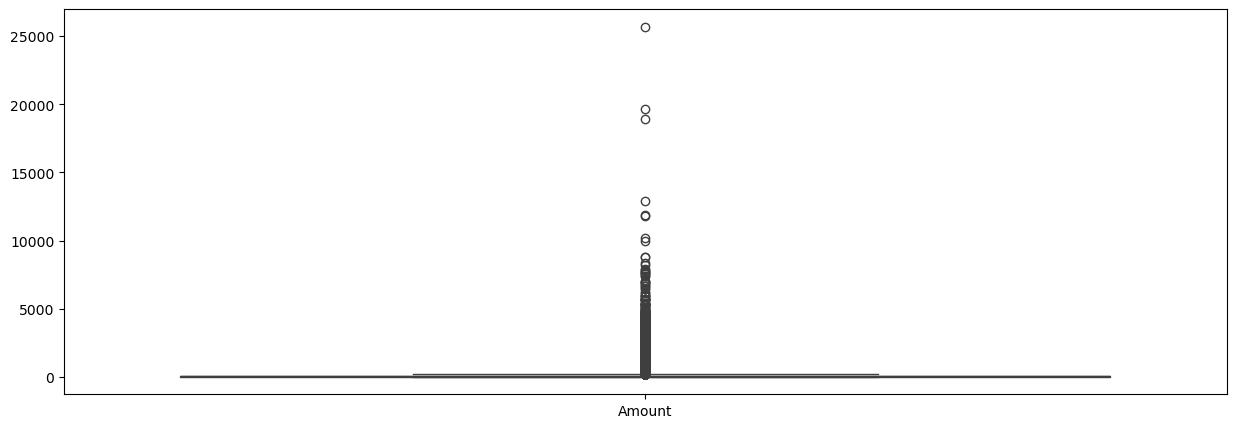

In [16]:
plt.figure(figsize=(15,5))
sns.boxplot(data=data[['Amount']])
plt.show()

### Observation

Several extreme transaction amounts exist within the dataset.

### Insight

Outliers may represent genuine fraud cases or unusual customer behavior.

### Business Impact

Proper outlier analysis improves fraud detection reliability.

In [17]:
X=data.drop(['Class'],axis=1)
y=data['Class']

## Train-Test Split

The dataset was divided into:

- Training Set (80%)
- Testing Set (20%)

### Purpose

To evaluate model performance on unseen transaction data.

In [18]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## Model Training

Multiple machine learning algorithms were trained and compared.

Models Used:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

### Goal

Identify the most effective fraud detection model.

In [19]:
LR=LogisticRegression()
LR.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
y_pred_LR=LR.predict(x_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred_LR))
print("Precision:", precision_score(y_test, y_pred_LR))
print("Recall:", recall_score(y_test, y_pred_LR))
print("F1-score:", f1_score(y_test, y_pred_LR))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_LR))
LR_ACC = accuracy_score(y_test, y_pred_LR)
LR_ACC

Accuracy: 0.9985955549313578
Precision: 0.5571428571428572
Recall: 0.5735294117647058
F1-score: 0.5652173913043478
Confusion Matrix:
 [[85245    62]
 [   58    78]]


0.9985955549313578

In [ ]:
RFC=RandomForestClassifier()
RFC.fit(x_train,y_train)

In [ ]:
y_pred_RFC=RFC.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_RFC))
print("Precision:", precision_score(y_test, y_pred_RFC))
print("Recall:", recall_score(y_test, y_pred_RFC))
print("F1-score:", f1_score(y_test, y_pred_RFC))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_RFC))
RFC_ACC = accuracy_score(y_test, y_pred_RFC)
RFC_ACC

In [ ]:
SVM=SVC()
SVM.fit(x_train,y_train)

In [ ]:
y_pred_SVM=SVM.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("Precision:", precision_score(y_test, y_pred_SVM))
print("Recall:", recall_score(y_test, y_pred_SVM))
print("F1-score:", f1_score(y_test, y_pred_SVM))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))
SVM_ACC = accuracy_score(y_test, y_pred_SVM)
SVM_ACC

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

In [ ]:
y_pred_dt=dt.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
DT_ACC = accuracy_score(y_test, y_pred_dt)
DT_ACC

In [ ]:
xgb=XGBClassifier(n_estimators=10)
xgb.fit(x_train,y_train)

In [ ]:
y_pred_xgb=xgb.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
XGB_ACC = accuracy_score(y_test, y_pred_xgb)
XGB_ACC

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM","XGBoost"],
    "Accuracy":[LR_ACC,DT_ACC,RFC_ACC,SVM_ACC,XGB_ACC]
})

results.sort_values(by="Accuracy",ascending=False)

In [ ]:
models=['Logistic Regression','Decision Tree','Random Forest','XGBoost','SVM']
scores=[0.998596,0.999087,0.999625,0.999555,0.998408]

plt.bar(models,scores)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()

### Observation

Random Forest achieved the highest performance among tested models.

### Insight

Ensemble models effectively capture complex fraud patterns.

### Business Impact

Higher detection accuracy reduces financial losses and customer complaints.

In [ ]:
import joblib

joblib.dump(RFC, "credit_model.pkl")